<a href="https://colab.research.google.com/github/Vishalpardeshi-31/Placement-Prediction-Model/blob/main/CGPA_IQ_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv('placment_data.csv')

df.head()


,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [ ]:
import numpy as np
import pandas as pd


df = pd.read_csv('placment_data.csv')
df = df.drop(columns=['College_ID','Prev_Sem_Result','Academic_Performance','Internship_Experience','Extra_Curricular_Score','Communication_Skills','Projects_Completed'])
df.head()


,IQ,CGPA,Placement
0,107,6.28,No
1,97,5.37,No
2,109,5.83,No
3,122,5.75,No
4,96,7.69,No


In [ ]:
df.shape

(10000, 3)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IQ         10000 non-null  int64  
 1   CGPA       10000 non-null  float64
 2   Placement  10000 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 234.5+ KB


In [ ]:
df['Placement'] = df['Placement'].replace({'Yes': 1, 'No': 0})
df.head()

/tmp/ipykernel_2035/735404807.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Placement'] = df['Placement'].replace({'Yes': 1, 'No': 0})


,IQ,CGPA,Placement
0,107,6.28,0
1,97,5.37,0
2,109,5.83,0
3,122,5.75,0
4,96,7.69,0


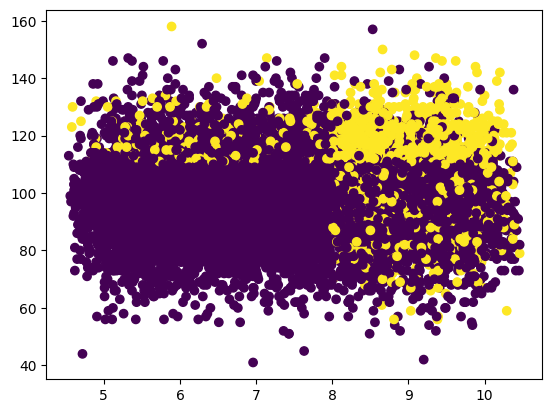

In [ ]:
 import matplotlib.pyplot as plt

plt.scatter(df['CGPA'],df['IQ'],c= df['Placement'])


In [ ]:
X = df[['CGPA', 'IQ']]
Y = df['Placement']

In [ ]:
X

,CGPA,IQ
0,6.28,107
1,5.37,97
2,5.83,109
3,5.75,122
4,7.69,96
...,...,...
9995,8.29,119
9996,9.34,70
9997,6.25,89
9998,8.92,107


In [ ]:
Y

,Placement
0,0
1,0
2,0
3,0
4,0
...,...
9995,1
9996,0
9997,0
9998,0


In [ ]:
import sklearn
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test =train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
X_train

,CGPA,IQ
9254,6.96,103
1561,5.02,88
1670,6.99,96
6087,6.22,76
6669,8.06,110
...,...,...
5734,9.72,91
5191,7.36,99
5390,6.66,89
860,7.57,103


In [ ]:
X_test

,CGPA,IQ
6252,7.24,139
4684,8.49,84
1731,5.66,94
4742,6.29,100
4521,6.39,116
...,...,...
6412,7.40,72
8285,7.95,114
7853,8.81,108
1095,9.63,98


In [ ]:
Y_test

,Placement
6252,0
4684,0
1731,0
4742,0
4521,1
...,...
6412,0
8285,0
7853,0
1095,0


In [ ]:
Y_train

,Placement
9254,0
1561,0
1670,0
6087,0
6669,0
...,...
5734,0
5191,0
5390,0
860,0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train =scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train

array([[-0.38674212,  0.22949886],
       [-1.70492153, -0.76655391],
       [-0.3663579 , -0.23532577],
       ...,
       [-0.5905843 , -0.70015039],
       [ 0.02773697,  0.22949886],
       [-0.7128896 , -1.69620317]])

In [ ]:
X_test

array([[-0.19648942,  2.62002551],
       [ 0.65285299, -1.03216799],
       [-1.27005822, -0.3681328 ],
       ...,
       [ 0.87028464,  0.56151645],
       [ 1.42745326, -0.10251873],
       [-0.50225269, -1.0985715 ]])

In [ ]:
from sklearn.linear_model import LogisticRegression


clf = LogisticRegression()

clf.fit(X_train,Y_train)

LogisticRegression()

In [ ]:
X_test_scaled = scaler.transform(X_test)
Ypred = clf.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
Ypred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
Y_test


,Placement
6252,0
4684,0
1731,0
4742,0
4521,1
...,...
6412,0
8285,0
7853,0
1095,0


In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(Y_test,Ypred)

0.837

In [31]:
from sklearn.metrics import classification_report


print(f"Model Accuracy: {accuracy_score(Y_test,Ypred) * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(Y_test, Ypred))

Model Accuracy: 83.70%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1674
           1       0.00      0.00      0.00       326

    accuracy                           0.84      2000
   macro avg       0.42      0.50      0.46      2000
weighted avg       0.70      0.84      0.76      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Axes: >

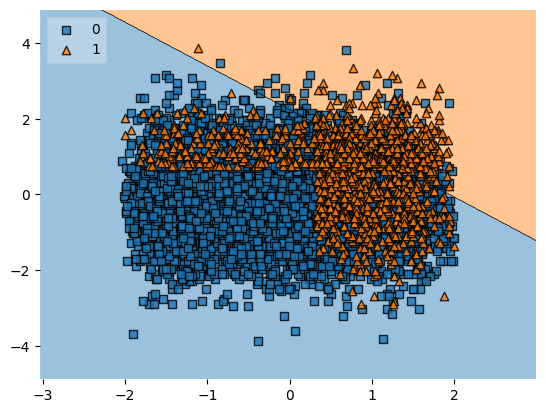

In [ ]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X_train, Y_train.values, clf=clf, legend=2)